In [ ]:
# XGBoost
# Gradient Boost

# Business Case :

### Based on given features we need to find whether an employee will leave the company or not.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
# from ydata_profiling import ProfileReport
from sklearn.preprocessing import StandardScaler,LabelEncoder,OneHotEncoder,OrdinalEncoder
import warnings
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
import pickle
from sklearn.pipeline import Pipeline
%matplotlib inline
warnings.filterwarnings('ignore')
#scikit learn 1.2.2 was used to write this notes

In [2]:
df=pd.read_csv("HR.csv")

# BASIC CHECKS

In [3]:
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


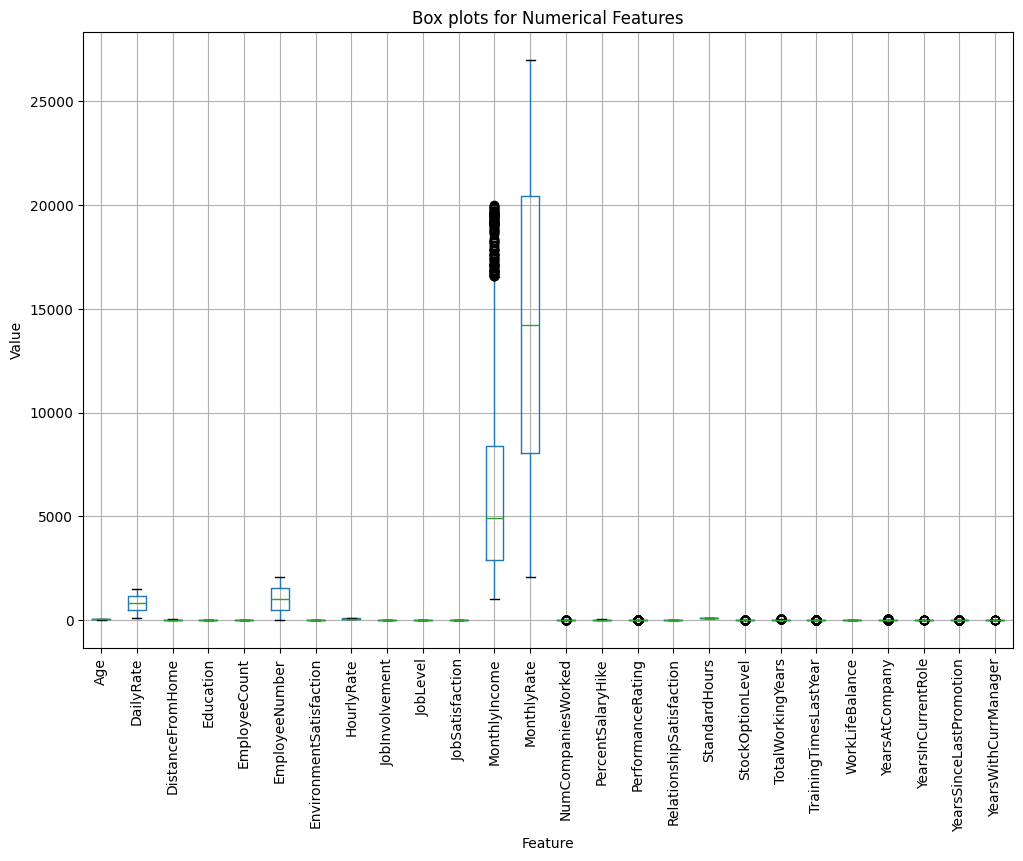

In [4]:
# Select numerical columns
numerical_cols = df.select_dtypes(include=['int', 'float']).columns

# Create box plots for all numerical features
plt.figure(figsize=(12, 8))
df[numerical_cols].boxplot()
plt.xticks(rotation=90)
plt.title('Box plots for Numerical Features')
plt.ylabel('Value')
plt.xlabel('Feature')
plt.show()


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

- There are no null values in the dataset.
- Attrition is the target column

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1470.0,36.923810,9.135373,18.0,30.00,36.0,43.00,60.0
DailyRate,1470.0,802.485714,403.509100,102.0,465.00,802.0,1157.00,1499.0
DistanceFromHome,1470.0,9.192517,8.106864,1.0,2.00,7.0,14.00,29.0
Education,1470.0,2.912925,1.024165,1.0,2.00,3.0,4.00,5.0
EmployeeCount,1470.0,1.000000,0.000000,1.0,1.00,1.0,1.00,1.0
EmployeeNumber,1470.0,1024.865306,602.024335,1.0,491.25,1020.5,1555.75,2068.0
EnvironmentSatisfaction,1470.0,2.721769,1.093082,1.0,2.00,3.0,4.00,4.0
HourlyRate,1470.0,65.891156,20.329428,30.0,48.00,66.0,83.75,100.0
JobInvolvement,1470.0,2.729932,0.711561,1.0,2.00,3.0,3.00,4.0
JobLevel,1470.0,2.063946,1.106940,1.0,1.00,2.0,3.00,5.0


In [8]:
df.describe(include = "O")

,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


# EDA

# INSIGHTS FROM EDA

## Try writing your own insights

# Correlation

<Figure size 2800x2800 with 0 Axes>

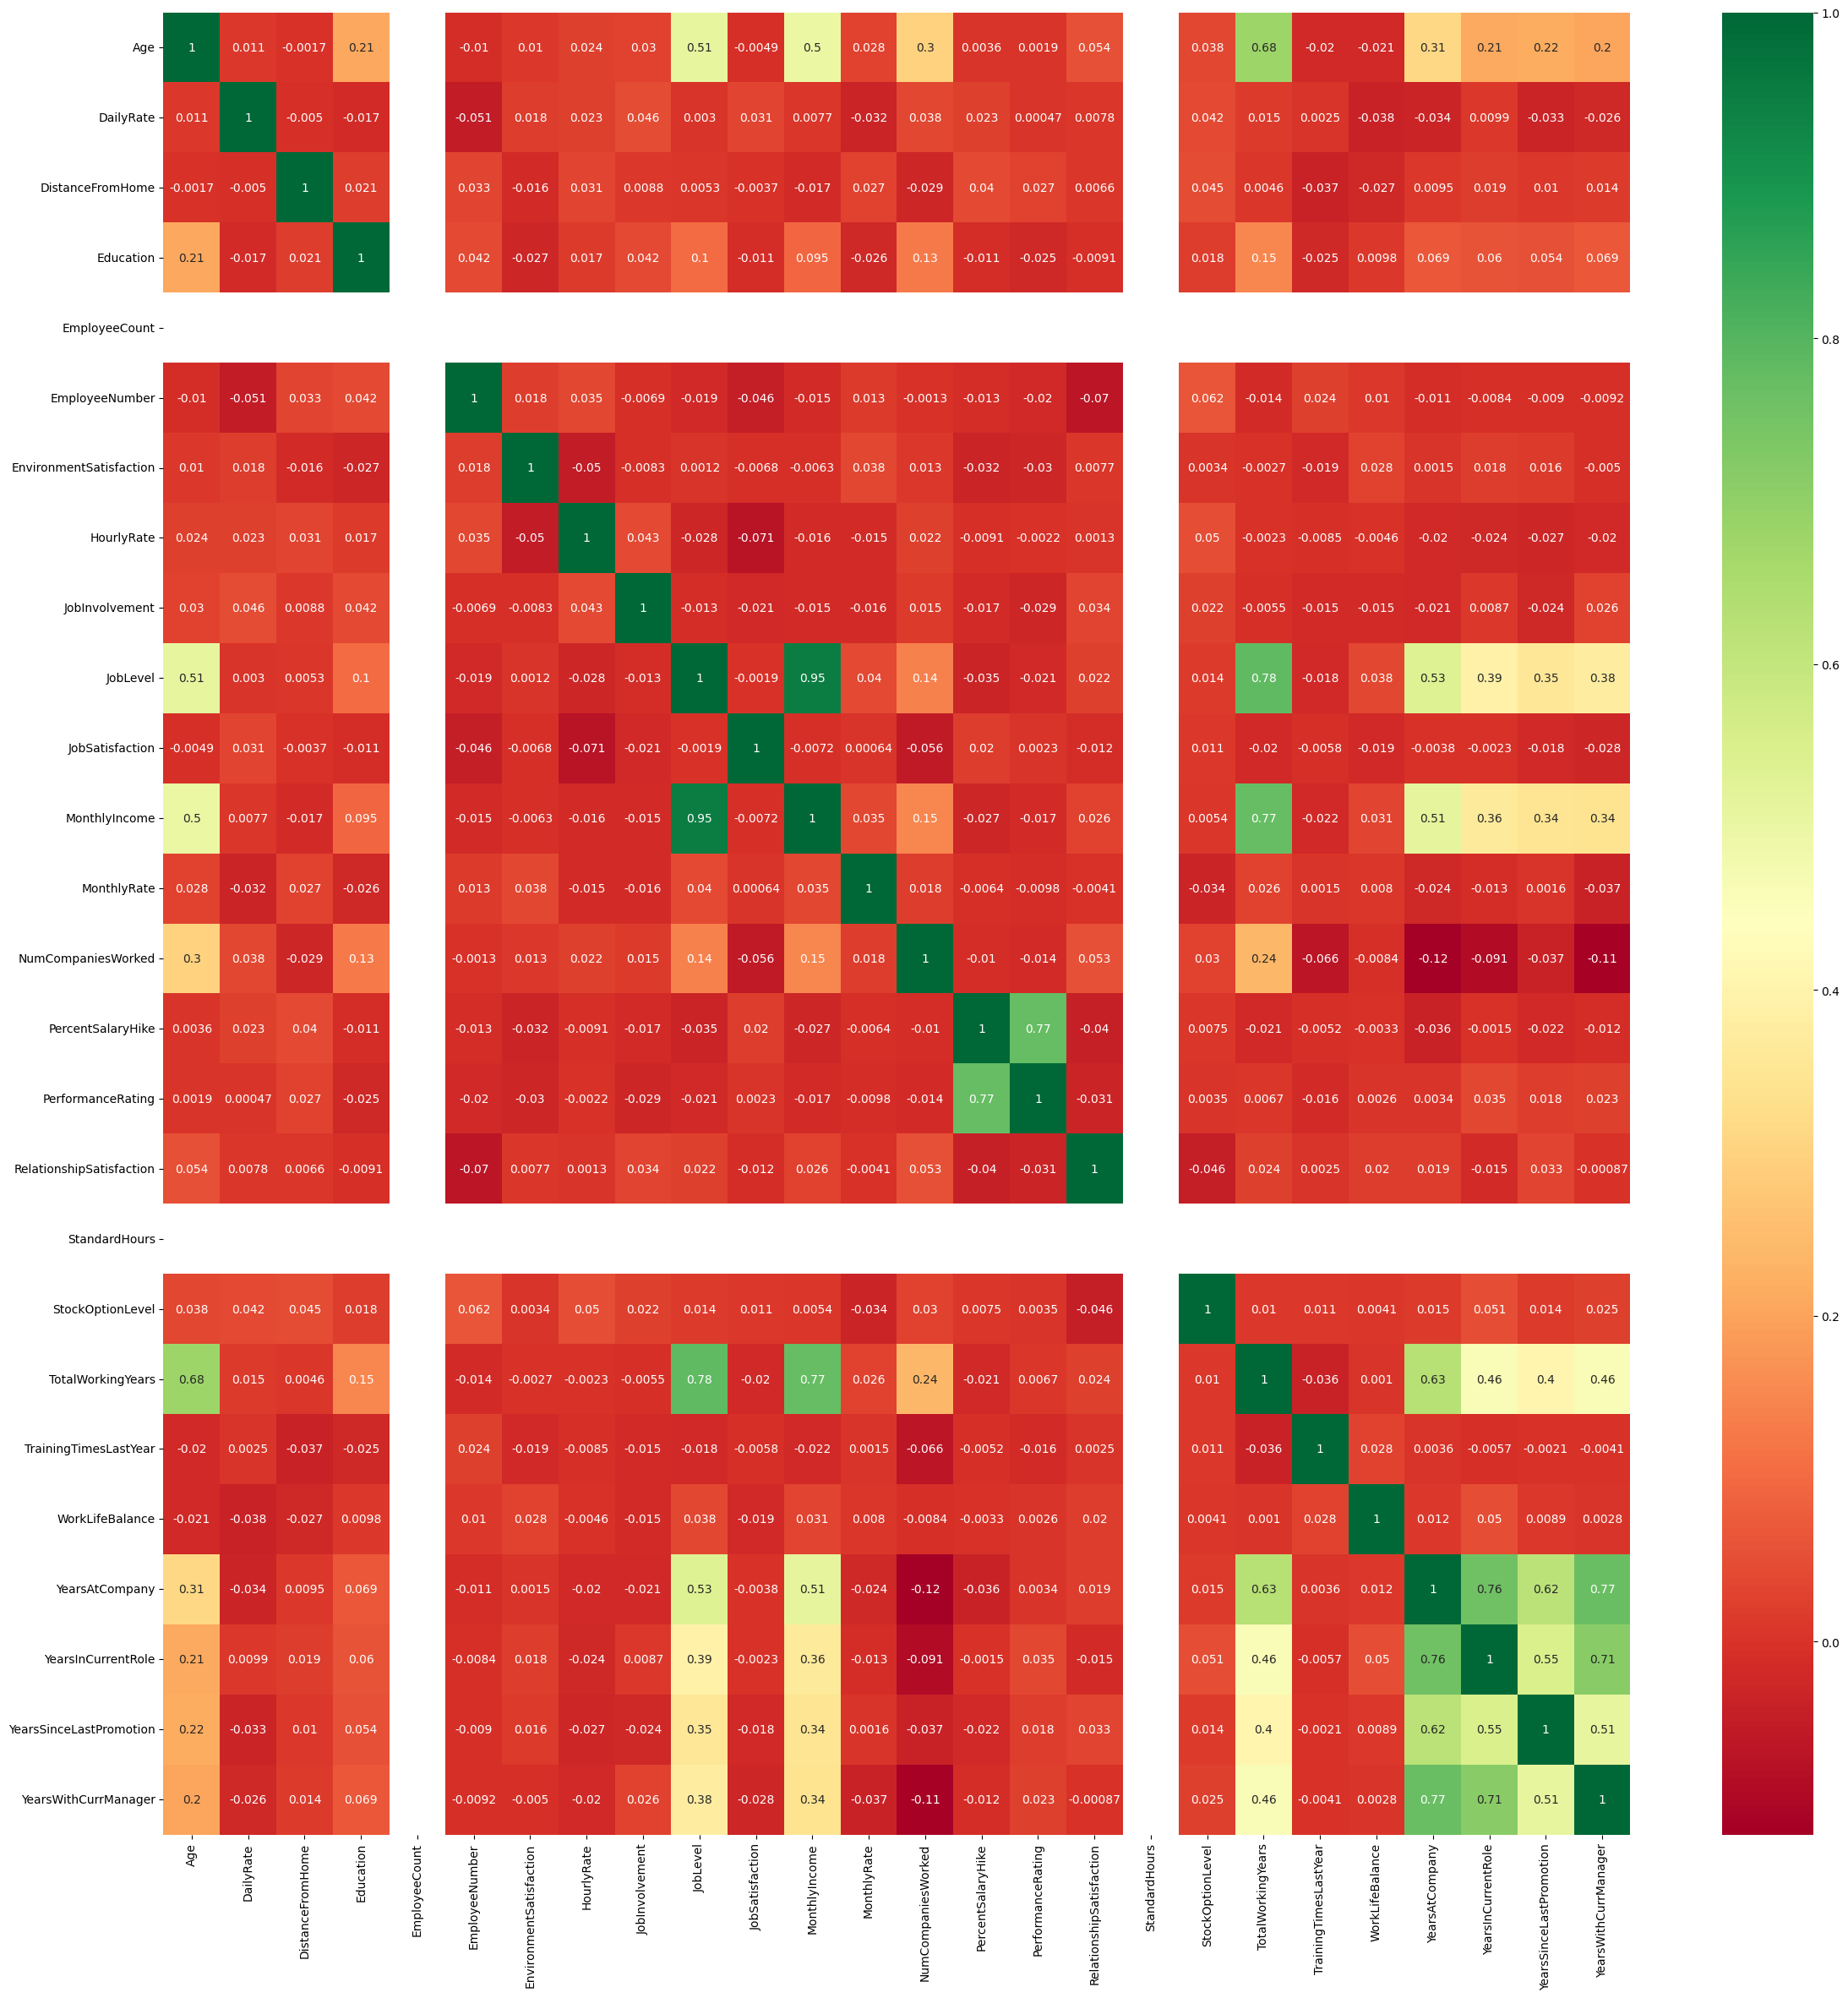

In [14]:
plt.figure(figsize=(28,28))#increase plot size
sns.heatmap(df.select_dtypes(include=['int', 'float']).corr(),cmap="RdYlGn",annot=True)
plt.show()

In [12]:
np.where(df.select_dtypes(include=['int', 'float']).corr()>0.9)

(array([ 0,  1,  2,  3,  5,  6,  7,  8,  9,  9, 10, 11, 11, 12, 13, 14, 15,
        16, 18, 19, 20, 21, 22, 23, 24, 25]),
 array([ 0,  1,  2,  3,  5,  6,  7,  8,  9, 11, 10,  9, 11, 12, 13, 14, 15,
        16, 18, 19, 20, 21, 22, 23, 24, 25]))

- There is a high correlation between JobLevel and MonthlyIncome hence the MonthlyIncome column can be dropped.

# PRE-PROCESSING

In [15]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

**The below columns are numerical columns having continuous values and hence we will apply Standard Scaler for all these columns**
- Age
- DailyRate
- DistanceFromHome
- MonthlyRate
- HourlyRate
- NumCompaniesWorked
- TotalWorkingYears
- TrainingTimesLastYear
- YearsAtCompany
- YearsInCurrentRole
- YearsSinceLastPromotion
- YearsWithCurrManager
- PercentSalaryHike

In [17]:
df[['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyRate', 'HourlyRate', 'NumCompaniesWorked', 'TotalWorkingYears',
    'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager','PercentSalaryHike']]

,Age,DailyRate,DistanceFromHome,MonthlyRate,HourlyRate,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PercentSalaryHike
0,41,1102,1,19479,94,8,8,0,6,4,0,5,11
1,49,279,8,24907,61,1,10,3,10,7,1,7,23
2,37,1373,2,2396,92,6,7,3,0,0,0,0,15
3,33,1392,3,23159,56,1,8,3,8,7,3,0,11
4,27,591,2,16632,40,9,6,3,2,2,2,2,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,884,23,12290,41,4,17,3,5,2,0,3,17
1466,39,613,6,21457,42,4,9,5,7,7,1,7,15
1467,27,155,4,5174,87,1,6,0,6,2,0,3,20
1468,49,1023,2,13243,63,2,17,3,9,6,0,8,14


# BusinessTravel :

In [18]:
df.BusinessTravel.value_counts()

BusinessTravel
Travel_Rarely        1043
Travel_Frequently     277
Non-Travel            150
Name: count, dtype: int64

- We will use One Hot Encoder for this column.

# Department :

In [19]:
df.Department.value_counts()

Department
Research & Development    961
Sales                     446
Human Resources            63
Name: count, dtype: int64

- We will use One hot encoder for this column.

# Education :

In [20]:
df.Education.value_counts()

Education
3    572
4    398
2    282
1    170
5     48
Name: count, dtype: int64

- The values are already arranged ordinally so we don't need to do anything.

# EducationField :

In [21]:
df.EducationField.value_counts()

EducationField
Life Sciences       606
Medical             464
Marketing           159
Technical Degree    132
Other                82
Human Resources      27
Name: count, dtype: int64

- We will use One Hot Encoder.


# EnvironmentSatisfaction :

In [22]:
df.EnvironmentSatisfaction.value_counts()

EnvironmentSatisfaction
3    453
4    446
2    287
1    284
Name: count, dtype: int64

- The values were already arranged ordinally so we don't have to do anything.

# Gender :

In [23]:
df.Gender.value_counts()

Gender
Male      882
Female    588
Name: count, dtype: int64

- We will apply One Hot Encoding to this column

# JobInvolvement :

In [24]:
df.JobInvolvement.value_counts()

JobInvolvement
3    868
2    375
4    144
1     83
Name: count, dtype: int64

- The values are already arranged in an orderly manner.

# JobLevel :

In [25]:
df.JobLevel.value_counts()

JobLevel
1    543
2    534
3    218
4    106
5     69
Name: count, dtype: int64

- The values are already arranged in an ordinal manner.

# JobRole :

In [26]:
df.JobRole.value_counts()

JobRole
Sales Executive              326
Research Scientist           292
Laboratory Technician        259
Manufacturing Director       145
Healthcare Representative    131
Manager                      102
Sales Representative          83
Research Director             80
Human Resources               52
Name: count, dtype: int64

- We will use one hot encoding.

# JobSatisfaction :

In [59]:
df.JobSatisfaction.value_counts()

JobSatisfaction
4    459
3    442
1    289
2    280
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# MaritalStatus :

In [60]:
df.MaritalStatus.value_counts()

MaritalStatus
Married     673
Single      470
Divorced    327
Name: count, dtype: int64

We will use One Hot Encoder for this column.

# OverTime :

In [61]:
df.OverTime.value_counts()

OverTime
No     1054
Yes     416
Name: count, dtype: int64

- We will use Label encoder for this column.


# PerformanceRating :

In [62]:
df.PerformanceRating.value_counts()

PerformanceRating
3    1244
4     226
Name: count, dtype: int64

- There are no changes to be made in this column since it is already present in an orderly manner.

# RelationshipSatisfaction :

In [63]:
df.RelationshipSatisfaction.value_counts()

RelationshipSatisfaction
3    459
4    432
2    303
1    276
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# StockOptionLevel :

In [64]:
df.StockOptionLevel.value_counts()

StockOptionLevel
0    631
1    596
2    158
3     85
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# TrainingTimesLastYear :

In [65]:
df.TrainingTimesLastYear.value_counts()

TrainingTimesLastYear
2    547
3    491
4    123
5    119
1     71
6     65
0     54
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

# WorkLifeBalance :

In [66]:
df.WorkLifeBalance.value_counts()

WorkLifeBalance
3    893
2    344
4    153
1     80
Name: count, dtype: int64

- This column is already arranged in an ordinal manner.

**All the columns that have a prior hierarchical order will be left as it is and Ordinal encoder will not be applied to such columns.**

# Creating the preprocessing pipeline :

In [67]:
len(df.columns)

35

In [27]:
OHE_columns=['BusinessTravel','Department','MaritalStatus','EducationField','Gender','JobRole']
standard_scaler=['Age', 'DailyRate', 'DistanceFromHome','MonthlyRate', 'HourlyRate', 'NumCompaniesWorked', 'TotalWorkingYears',
                 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager','PercentSalaryHike']
label_encoder=['OverTime']
passthrough=['Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','PercentSalaryHike','RelationshipSatisfaction',
             'StockOptionLevel','TrainingTimesLastYear','WorkLifeBalance','PerformanceRating']

# Steps of preprocesing for features:
- **LabelEncoder for**   :  'OverTime'
- **One hot encoder for**:  'BusinessTravel','Department','MaritalStatus','EducationField','Gender','JobRole'
- **Standard scaler for**:  'Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'MonthlyRate', 'HourlyRate', 'NumCompaniesWorked',
                            'TotalWorkingYears','TrainingTimesLastYear', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
                            'YearsWithCurrManager','PercentSalaryHike'
- **Pass through for**:     'Education','EnvironmentSatisfaction','JobInvolvement','JobLevel','JobSatisfaction','PercentSalaryHike',
                            'RelationshipSatisfaction','StockOptionLevel','TrainingTimesLastYear','WorkLifeBalance','PerformanceRating'


In [28]:
class ModifiedLabelEncoder(LabelEncoder):
    def fit_transform(self, y, *args, **kwargs):
        return super().fit_transform(y).reshape(-1, 1)

    def transform(self, y, *args, **kwargs):
        return super().transform(y).reshape(-1, 1)

In [29]:
def same(x):
    return x

In [30]:
no_trans=FunctionTransformer(same)

In [31]:
preprocessor = ColumnTransformer([
    ("OHE columns", OneHotEncoder(), OHE_columns),
    ("Label_encoder", ModifiedLabelEncoder(), label_encoder),
    ("Standard_scaler", StandardScaler(), standard_scaler),
    ('Pass_through',no_trans,passthrough)])

In [32]:
preprocessor

ColumnTransformer(transformers=[('OHE columns', OneHotEncoder(),
                                 ['BusinessTravel', 'Department',
                                  'MaritalStatus', 'EducationField', 'Gender',
                                  'JobRole']),
                                ('Label_encoder', ModifiedLabelEncoder(),
                                 ['OverTime']),
                                ('Standard_scaler', StandardScaler(),
                                 ['Age', 'DailyRate', 'DistanceFromHome',
                                  'MonthlyRate', 'HourlyRate',
                                  'NumCompaniesWorked', 'TotalWorkingYears',
                                  'Traini...
                                  'YearsSinceLastPromotion',
                                  'YearsWithCurrManager',
                                  'PercentSalaryHike']),
                                ('Pass_through',
                                 FunctionTransformer(func=<function same at 0x000002904FAA7EC0>),
                                 ['Education', 'EnvironmentSatisfaction',
                                  'JobInvolvement', 'JobLevel',
                                  'JobSatisfaction', 'PercentSalaryHike',
                                  'RelationshipSatisfaction',
                                  'StockOptionLevel', 'TrainingTimesLastYear',
                                  'WorkLifeBalance', 'PerformanceRating'])])

In [33]:
with open("preprocessing.pkl","wb") as f:
    pickle.dump(preprocessor,f)